In [1]:
# Below you will find the code for our mystery network, ready for your analysis
# Read the assignment instructions, and run through the code to figure out how to answer the questions
# Feel free to play with the values passed to the functions, but it is recommended not to change the code



### = Bill's Comments

In [2]:
# import the necessary libraries
import numpy as np
import numpy.random as random
import matplotlib.pyplot as plt
import pdb

In [3]:
#To ensure reproducibility
np.random.seed(11)

In [4]:
# Saturating Linear Function
def myfunction(X):
    """
    Takes in a matrix X, applies a saturating linear function to it, then returns it
    """

    # Normally would be an informative comment
    Y = X
    mask = (X < 0) 
    Y[mask] = 0
    mask = (X > 1)
    Y[mask] = 1
    return Y
 
# Likely adds a bias column 
def helper(inputs):
    """
    Normally would be an informative specification for the function
    """

    return np.append(inputs,np.ones((1,inputs.shape[1])),axis=0)

In [5]:
class task(object):
    """
    I would usually provide informative instructions and comments here, but that is not the point of 
    this assignment! Here, you need to analyze the code directly, using the PDP framework, and some insight.
    Answer the questions in the assignment instructions by analyzing the code below.
    """
    
    # Normally would be an informative comment
    def __init__(self,inputs,outputs):
        """
        Normally would be an informative specification for the function
        """
    
        # Normally would be an informative comment
        self.inputs  = np.array(inputs).transpose()
        self.outputs = np.array(outputs).transpose()

        # Normally would be an informative comment
        assert self.inputs.shape[1] == self.outputs.shape[1], "Number of cases in input and output not equal."
            
        
    # Normally would be an informative comment
    ### Number of Inputs
    def ncases(self):
        """
        Normally would be an informative specification for the function
        """
        return self.inputs.shape[1]
    
    # Normally would be an informative comment
    ### Number of values in each input
    def ninputs(self):
        """
        Normally would be an informative specification for the function
        """
        return self.inputs.shape[0]
    
    # Normally would be an informative comment
    ### Number of values in each output (Num classes)
    def noutputs(self):
        """
        Normally would be an informative specification for the function
        """
        return self.outputs.shape[0]

# Normally would be an informative comment
inputs  = ((0,0,0,0),(0,0,0,1),(0,0,1,0),(0,0,1,1),(0,1,0,0),(0,1,0,1),(0,1,1,0),(0,1,1,1),
           (1,0,0,0),(1,0,0,1),(1,0,1,0),(1,0,1,1),(1,1,0,0),(1,1,0,1),(1,1,1,0),(1,1,1,1))



outputs = ((0,0,0),(0,0,1),(0,1,0),(0,1,1),(1,0,0),(1,0,1),(1,1,0),(1,1,1),
           (1,1,1),(1,1,0),(1,0,1),(1,0,0),(0,1,1),(0,1,0),(0,0,1),(0,0,0))

ourtask = task(inputs,outputs)


In [6]:
class network(object):
    """
    I would usually provide informative instructions and comments here, but that is not the point of 
    this assignment! Here, you need to analyze the code directly, using the PDP framework, and some insight.
    Answer the questions in the assignment instructions by analyzing the code below.
    """
    
    # Normally would be an informative comment
    def __init__(self, task, N, eta, alpha):
        """
        Normally would be an informative specification for the function
        """
        self.task  = task
        self.N     = N
        self.eta   = eta
        self.alpha = alpha
        self.W0   = random.normal(scale=self.alpha,size=(self.N, self.task.ninputs()+1))
        self.W1   = random.normal(scale=self.alpha,size=(self.task.noutputs(),self.N+1))
    
    # Normally would be an informative comment
    def forward(self):
        """
        Normally would be an informative specification for the function
        """
            
        # Layer 1: Matmul and then activation
        tensor0 = myfunction(np.dot(self.W0,helper(self.task.inputs))) 
        # Layer 2: Matmul and then activation
        tensor1 = myfunction(np.dot(self.W1,helper(tensor0)))
                      
        return (tensor0,tensor1)
                           
    # Loss Function
    def important_function(self,tensor1):
        """
        Compute Loss/Error
        """
        print(tensor1)
        print(np.shape(tensor1))
        return np.mean(np.sum((self.task.outputs - tensor1)**2,axis=0))
    
    # Normally would be an informative comment
    def one_loop(self):
        """
        Normally would be an informative specification for the function
        """
        # Normally would be an informative comment


        (tensor0,tensor1) = self.forward() ###Run a forward pass (inference)

        error    = self.task.outputs - tensor1 ### compare inference to actual

        delta_W0 = np.dot(np.dot(self.W1[:,:-1].transpose(),error),helper(self.task.inputs).transpose()) ### Backward pass for first layer, calculates gradient
        
        delta_W1 = np.dot(error,helper(tensor0).transpose()) ### Backward pass for output layer, calculates gradient
        
        # Normally would be an informative comment
        self.W0 += self.eta*delta_W0
        self.W1 += self.eta*delta_W1 ### Updates the weights with the learning rate ETA (greek)
        #pdb.set_trace()
        
        return tensor1
    
    # Normally would be an informative comment
    def make_ready(self, M):
        """
        Normally would be an informative specification for the function
        """
        
        # Normally would be an informative comment
        important_values = np.zeros((M,))
        
        # Normally would be an informative comment
        ### Train network while graphing the train loss each time
        for m in range(M):
            tensor1 = self.one_loop()
            important_values[m] = self.important_function(tensor1)
        
        # Normally would be an informative comment
        ### Plot the loss value vs the number of iterations
        plt.plot(important_values)
        plt.ylabel("Important function")
        plt.xlabel("Number of loops")
        plt.show()

        plt.imshow(self.W0)
        plt.colorbar()
        plt.show()
        plt.imshow(self.W1)
        plt.colorbar()
        plt.show()


[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.5733829
  0.         0.         0.59512245 0.26818723 0.         0.
  0.         0.         0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.06680892 0.         0.         0.
  0.98100858 0.         0.         0.        ]]
(3, 16)
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
(3, 16)
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]
(3, 16)
[[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]]
(3, 1

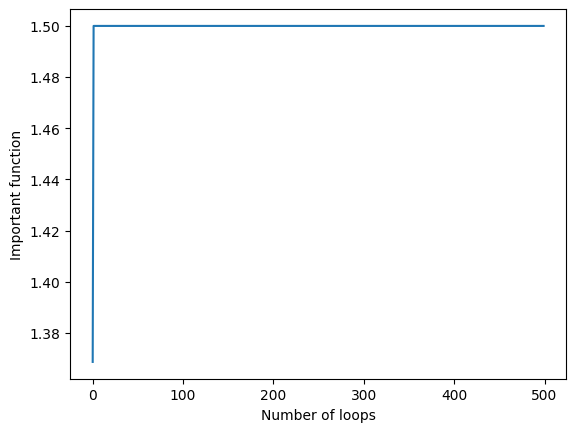

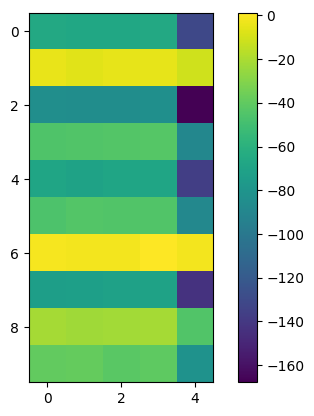

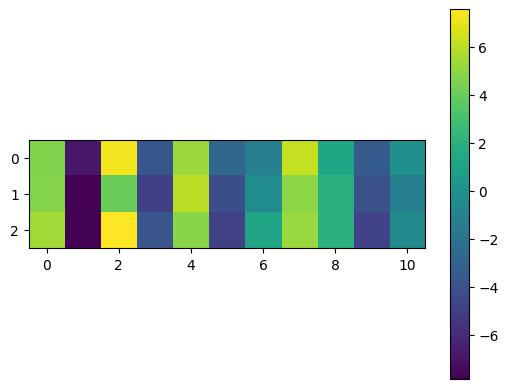

In [32]:
# Normally would be an informative commenty
N     =10  # default: 100, but feel free to play with this value #Hidden Layer
eta   = 1 # default: 0.01, but feel free to play with this value
alpha = 1.0  # default: 1.0, but feel free to play with this value
M     = 500  # default: 500, but feel free to play with this value

ournet = network(ourtask,N,eta,alpha)
ournet.make_ready(M)



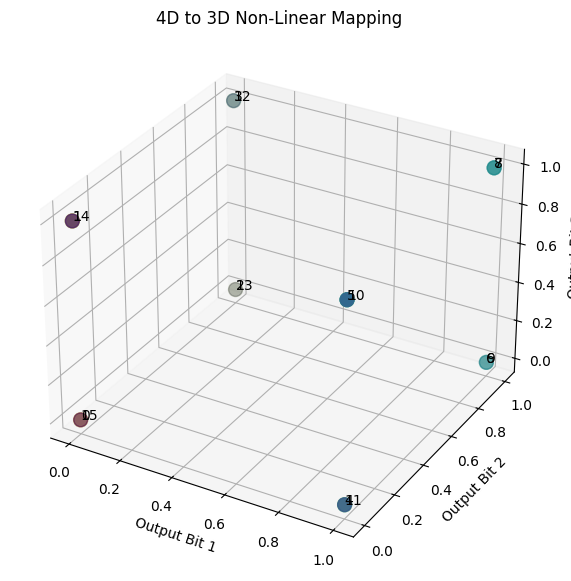

In [8]:
from mpl_toolkits.mplot3d import Axes3D

# Define the 4-bit binary inputs (all 16 possible inputs)
binary_inputs = np.array([
    [0,0,0,0], [0,0,0,1], [0,0,1,0], [0,0,1,1],
    [0,1,0,0], [0,1,0,1], [0,1,1,0], [0,1,1,1],
    [1,0,0,0], [1,0,0,1], [1,0,1,0], [1,0,1,1],
    [1,1,0,0], [1,1,0,1], [1,1,1,0], [1,1,1,1]
])

# Define the corresponding 3-bit binary outputs (simulated, as we don’t have your actual network output)
# Assuming the mapping follows a structured pattern, but these values could be replaced by actual network output
binary_outputs = np.array([
    [0,0,0], [0,0,1], [0,1,0], [0,1,1],
    [1,0,0], [1,0,1], [1,1,0], [1,1,1],
    [1,1,1], [1,1,0], [1,0,1], [1,0,0],
    [0,1,1], [0,1,0], [0,0,1], [0,0,0]
])

# Convert binary outputs to decimal coordinates (for easier 3D plotting)
decimal_outputs = np.dot(binary_outputs, [4, 2, 1])  # Convert 3-bit binary to decimal

# Convert binary inputs to decimal for labeling
decimal_inputs = np.dot(binary_inputs, [8, 4, 2, 1])  # Convert 4-bit binary to decimal

# Create a 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of 3D outputs
ax.scatter(binary_outputs[:, 0], binary_outputs[:, 1], binary_outputs[:, 2], c=decimal_inputs, cmap='viridis', s=100)

# Annotate each point with its corresponding 4-bit input
for i in range(len(binary_inputs)):
    ax.text(binary_outputs[i, 0], binary_outputs[i, 1], binary_outputs[i, 2], f"{decimal_inputs[i]}", fontsize=10, color='black')

# Labels
ax.set_xlabel('Output Bit 1')
ax.set_ylabel('Output Bit 2')
ax.set_zlabel('Output Bit 3')
ax.set_title('4D to 3D Non-Linear Mapping')

plt.show()

In [9]:
from scipy.interpolate import Rbf

# Use Radial Basis Function (RBF) interpolation for a smoother surface
rbf_interpolator = Rbf(x, y, z, function='multiquadric', smooth=0.1)

# Generate a fine grid for interpolation
grid_x, grid_y = np.mgrid[0:1:50j, 0:1:50j]
grid_z_rbf = rbf_interpolator(grid_x, grid_y)

# Create a 3D plot with the RBF-interpolated surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot of original 3D outputs
ax.scatter(x, y, z, c=decimal_inputs, cmap='viridis', s=100, label="MLP Outputs")

# Overlay a smooth Radial Basis Function (RBF) interpolated surface
ax.plot_surface(grid_x, grid_y, grid_z_rbf, cmap='coolwarm', alpha=0.6)

# Labels
ax.set_xlabel('Output Bit 1')
ax.set_ylabel('Output Bit 2')
ax.set_zlabel('Output Bit 3')
ax.set_title('Overlay: 4D to 3D Non-Linear Mapping with RBF Interpolation')

plt.legend()
plt.show()

NameError: name 'x' is not defined

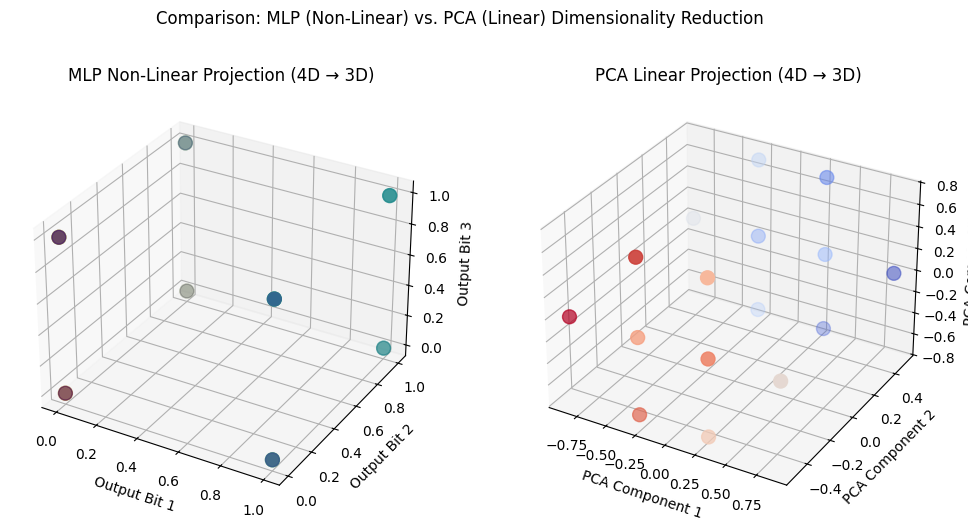

In [34]:
from sklearn.decomposition import PCA

# Apply PCA to reduce the 4D input space to 3D
pca = PCA(n_components=3)
pca_outputs = pca.fit_transform(binary_inputs)  # PCA projects inputs to 3D

# Create a 3D scatter plot to compare PCA vs. MLP
fig = plt.figure(figsize=(12, 6))

# MLP Output Plot
ax1 = fig.add_subplot(121, projection='3d')
ax1.scatter(binary_outputs[:, 0], binary_outputs[:, 1], binary_outputs[:, 2], c=decimal_inputs, cmap='viridis', s=100)
ax1.set_title('MLP Non-Linear Projection (4D → 3D)')
ax1.set_xlabel('Output Bit 1')
ax1.set_ylabel('Output Bit 2')
ax1.set_zlabel('Output Bit 3')

# PCA Output Plot
ax2 = fig.add_subplot(122, projection='3d')
ax2.scatter(pca_outputs[:, 0], pca_outputs[:, 1], pca_outputs[:, 2], c=decimal_inputs, cmap='coolwarm', s=100)
ax2.set_title('PCA Linear Projection (4D → 3D)')
ax2.set_xlabel('PCA Component 1')
ax2.set_ylabel('PCA Component 2')
ax2.set_zlabel('PCA Component 3')

plt.suptitle('Comparison: MLP (Non-Linear) vs. PCA (Linear) Dimensionality Reduction')
plt.show()

In [35]:

test_inputs = np.random.rand(16, 4)
# Layer 1: Matmul and then activation
tensor0 = myfunction(np.dot(ournet.W0,helper(np.array(test_inputs).transpose()))) 
# Layer 2: Matmul and then activation
tensor1 = myfunction(np.dot(ournet.W1,helper(tensor0)))

print(tensor1)

[[0.54346881 0.59284214 0.47176824 0.62049756 0.80072238 0.62314395
  0.79008125 0.60057409 0.60907799 0.59535228 0.7505641  0.68720628
  0.46097724 0.63699623 0.55141366 0.46097724]
 [0.31665726 0.05545466 0.81177919 0.25488243 0.         0.31596729
  0.         0.36613836 0.20906724 0.15025444 0.         0.01103387
  0.84776747 0.         0.16473152 0.84776747]
 [0.00245672 0.15229753 0.49701812 0.         0.         0.06143083
  0.         0.86118835 0.         0.0212798  0.         0.31245127
  0.52878237 0.         0.         0.52878237]]
